# LeetCode #14: Longest Common Prefix



https://leetcode.com/problems/longest-common-prefix/



## Comparison of Approaches



| Approach | Time Complexity | Space Complexity |

| :--- | :--- | :--- |

| **Horizontal Scanning** | $O(S)$ | $O(1)$ |

| **Optimal: Vertical Scanning** ★ | $O(S)$ | $O(1)$ |



---



## Understanding the Methods



### Horizontal Scanning

Take `strs[0]` as the running prefix. For each subsequent string, trim the prefix from the right until it becomes a prefix of that string. Requires repeated `StartsWith` checks and can re-scan the same prefix characters multiple times across strings.



### Optimal: Vertical Scanning ★

Compare character by character across **all** strings simultaneously, column by column. The moment any string mismatches or ends, return `strs[0][0..col]`. Never revisits a character that was already confirmed as matching.



**Why this is better than Horizontal Scanning:** Same $O(S)$ worst-case, but vertical scanning exits at the **first diverging column** and performs at most one pass over all confirmed prefix characters. Horizontal scanning can re-examine the same prefix characters for each string it compares against.



**Constraints:**

* `1 <= strs.length <= 200`

* `0 <= strs[i].length <= 200`

* `strs[i]` consists of only lowercase English letters

## Solutions



### C#

In [ ]:
public class Solution {

    public string LongestCommonPrefix(string[] strs) {

        for (int col = 0; col < strs[0].Length; col++) {

            char c = strs[0][col];

            // Check this column across all strings

            for (int row = 1; row < strs.Length; row++) {

                if (col == strs[row].Length || strs[row][col] != c)

                    return strs[0].Substring(0, col);

            }

        }

        return strs[0];

    }

}

### Python

In [ ]:
class Solution:

    def longestCommonPrefix(self, strs: list[str]) -> str:

        for col in range(len(strs[0])):

            c = strs[0][col]

            # Check this column across all strings

            for row in range(1, len(strs)):

                if col == len(strs[row]) or strs[row][col] != c:

                    return strs[0][:col]

        return strs[0]

### Go

In [ ]:
func longestCommonPrefix(strs []string) string {

    for col := 0; col < len(strs[0]); col++ {

        c := strs[0][col]

        // Check this column across all strings

        for row := 1; row < len(strs); row++ {

            if col == len(strs[row]) || strs[row][col] != c {

                return strs[0][:col]

            }

        }

    }

    return strs[0]

}

### Rust

In [ ]:
impl Solution {

    pub fn longest_common_prefix(strs: Vec<String>) -> String {

        let first = strs[0].as_bytes();

        for col in 0..first.len() {

            // Check this column across all strings

            for row in 1..strs.len() {

                let s = strs[row].as_bytes();

                if col == s.len() || s[col] != first[col] {

                    return strs[0][..col].to_string();

                }

            }

        }

        strs[0].clone()

    }

}

## Example Scenarios



**Example 1 — Common Case**\

**Input:** `strs = ["flower","flow","flight"]`\

Col 0: f=f=f ✓. Col 1: l=l=l ✓. Col 2: o vs o vs i → mismatch at "flight"[2]. Return `strs[0][:2]` = "fl" → **"fl"**.



**Example 2 — Slightly Complex**\

**Input:** `strs = ["dog","racecar","car"]`\

Col 0: d vs r → mismatch on the very first column. Return `strs[0][:0]` = "" — no common prefix at all → **""**.



**Example 3 — Edge Case: Time Factor**\

**Input:** `strs = ["aaaaa","aaaaa","aaaaa","aaaaa"]`\

All strings identical: every column check passes, the outer loop exhausts all 5 columns, the inner loop checks all 3 remaining strings per column. $5 \times 4 = 20$ character comparisons — maximum work for strings of this length → **"aaaaa"**.



**Example 4 — Edge Case: Space Factor**\

**Input:** `strs = ["abc","ab","abcd"]`\

Cols 0–1 confirm "ab". At col 2, `strs[1].length == 2 == col` triggers the length guard: string ended before a character mismatch. Returns `strs[0][:2]`. Only one integer (`col`) and one char (`c`) held in memory beyond the output → **"ab"**.



**Example 5 — Almost-Impossible but Plausible**\

**Input:** `strs = ["interview","intercom","internal","interact"]`\

Cols 0–4 confirm "inter" across all four strings ($5 \times 3 = 15$ comparisons pass). Col 5: "interview"[5]='v', "intercom"[5]='c' → mismatch. Five confirmed prefix characters, then one final mismatch → **"inter"**.

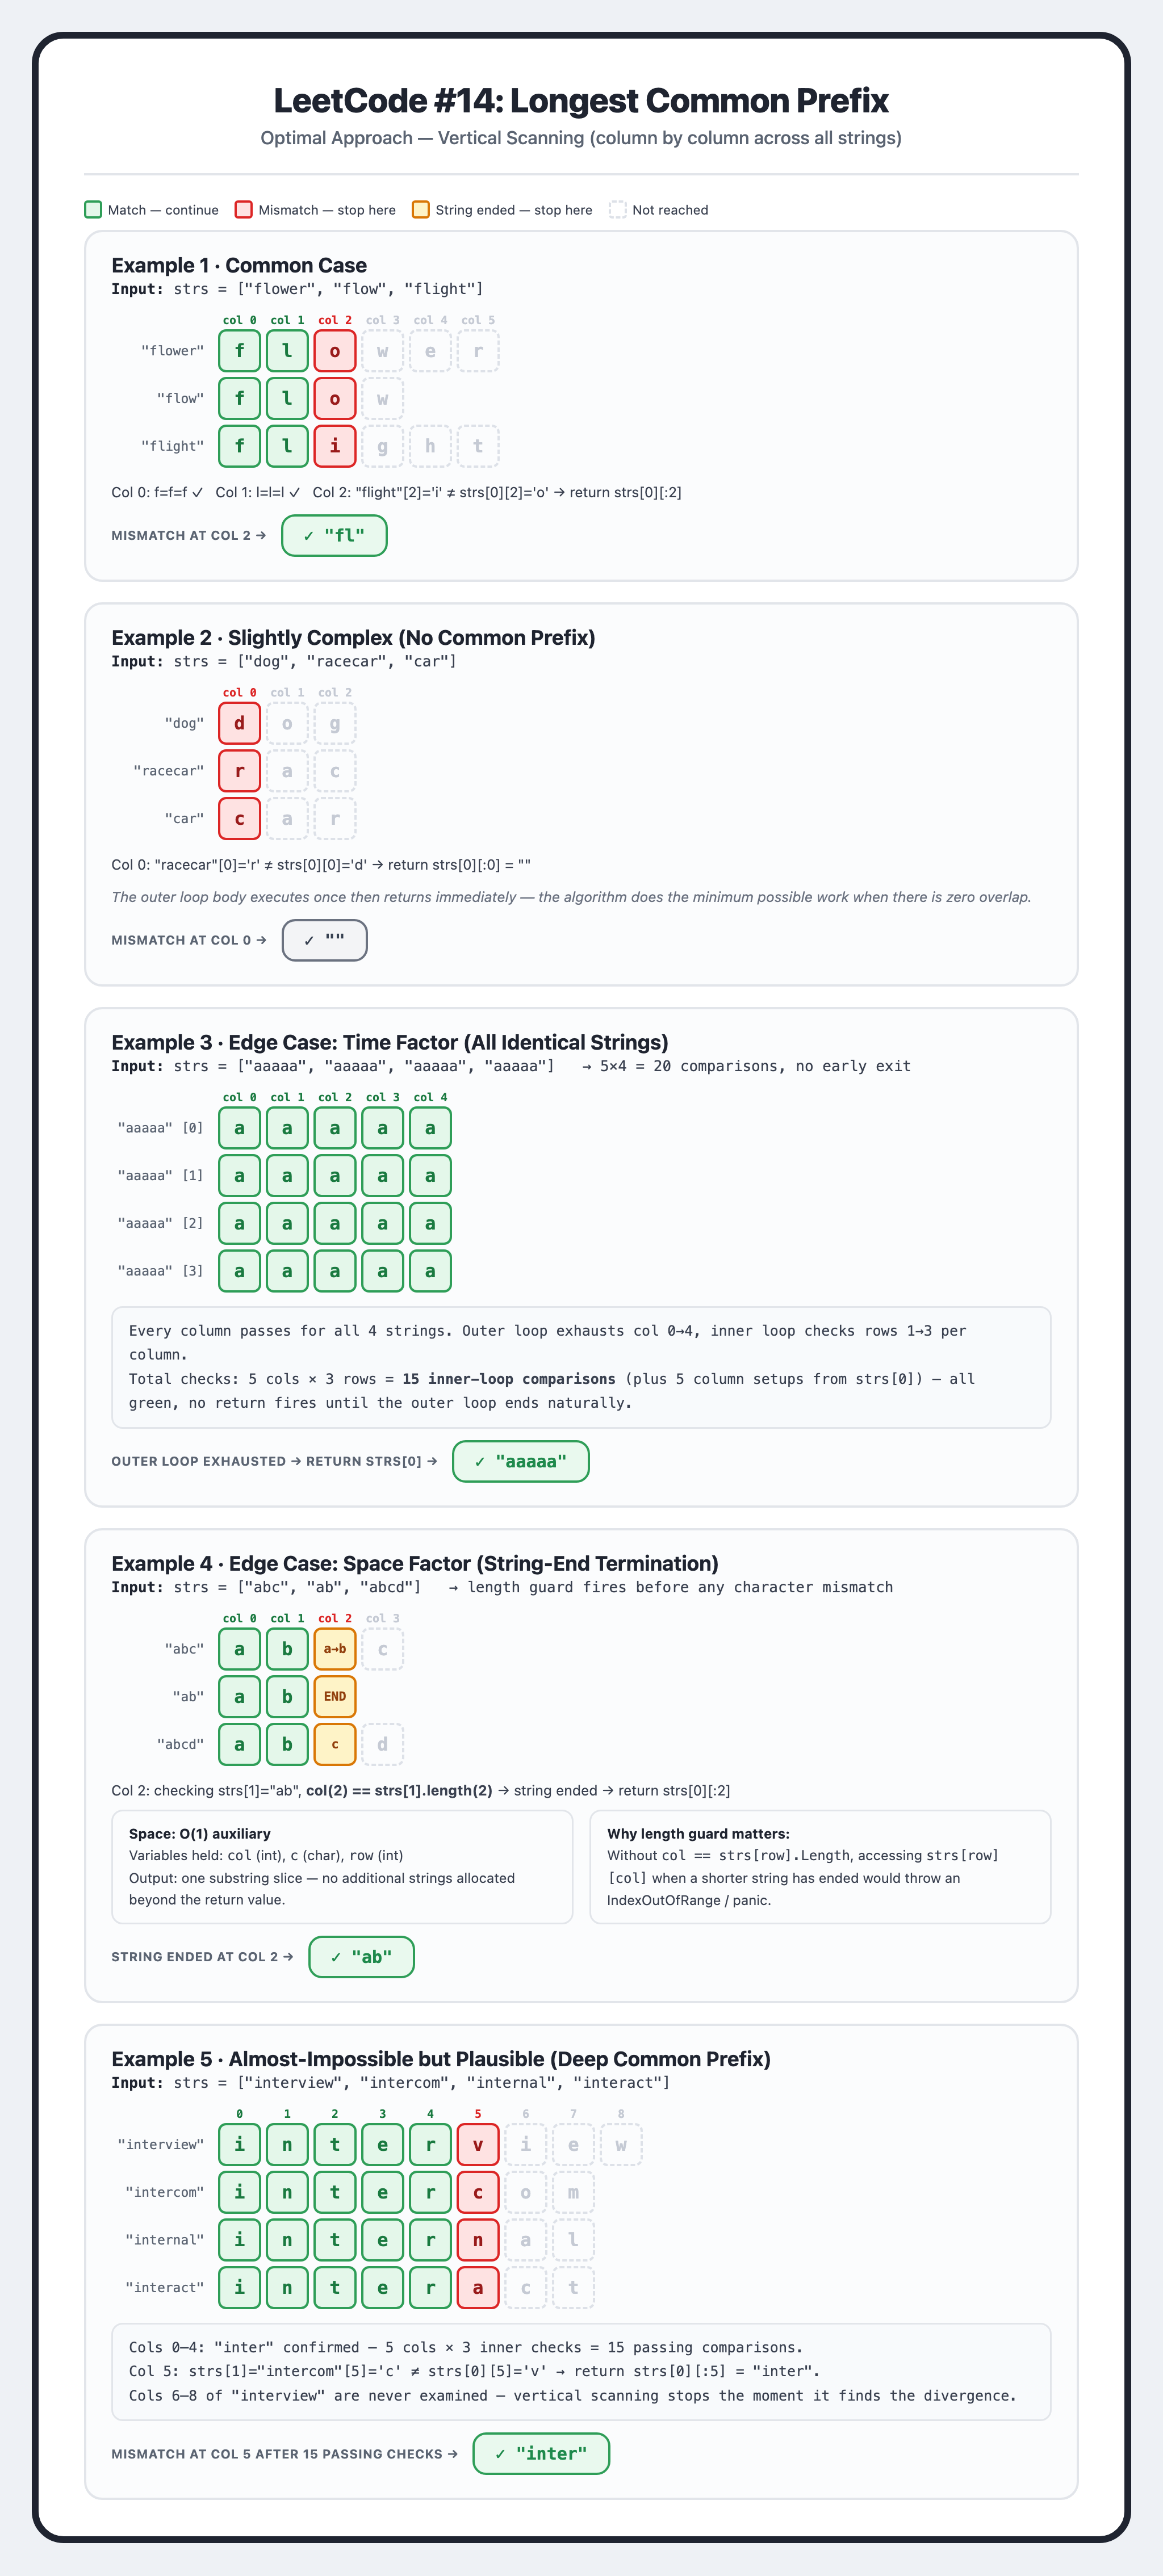